# Static augmentation

## Overview

This workflow uses a **"static" data augmentation workflow** for vertebrallandmark localization in sagittal spine MRI.  
**All augmentations are applied at dataset level** and remain **fixed across training**, ensuring stable optimization and reproducibility.

The model is trained to predict **heatmaps** for predefined anatomical levels (e.g. L1/L2 – L5/S1), from which landmark coordinates are extracted via argmax.

## Augmentation Strategy

Augmentations are applied **only to the training dataset**.  
Validation and test datasets remain **unaltered**.

### 1. Paired Geometric Augmentations (Image + Heatmaps)

These transformations are applied **identically** to the image and its corresponding heatmaps to preserve spatial alignment:

- Random rotation (extended range, e.g. ±15°)
- Random translation (percentage of image size)
- Random scaling
- Random shear
- Horizontal flip
- Vertical flip

This ensures that landmark supervision remains geometrically correct after transformation.

---

### 2. Image-only Intensity Augmentations

These transformations affect **only the input image**, not the heatmaps:

- Brightness adjustment
- Contrast adjustment
- Gamma correction
- Gaussian blur
- Optional noise (if enabled)

Intensity augmentations simulate acquisition variability across scanners and protocols.

---

## Training Workflow

1. Dataset is constructed with static augmentation enabled for training.
2. Model is trained using:
   - Heatmap regression loss (e.g. weighted MSE)
   - Automatic Mixed Precision (AMP) if GPU is available
3. Early stopping is applied based on validation loss.
4. Best-performing model weights are restored in memory.
5. Training and validation losses are visualized after training.

Optional schedules (sigma reduction or resolution increase) can be enabled, but the **augmentation itself remains static**.

---


## Data preprocessing

In [1]:
import os, glob
import numpy as np
import pandas as pd
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import cv2
import re
from PIL import Image
import torch
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
from torch.utils.data import random_split, DataLoader
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

2026-01-15 23:02:21.761267: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 23:02:21.775020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768514541.789129 2684662 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768514541.793221 2684662 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-15 23:02:21.809174: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
%run ./Pretraining-datasets.ipynb

In [3]:
%run ./Pretraining-models.ipynb

In [59]:
%run ./Pretraining-fce.ipynb

In [5]:
BASE_DIR = Path.cwd()
print(BASE_DIR)

/home/jupyter-lukj08@vse.cz/BC/Pre-training


In [6]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"       # quieter logs (optional)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"  # enables growth mode
torch.cuda.is_available(), torch.cuda.get_device_name(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
df_coords = pd.read_csv("df_coords.csv")
print("Loaded df_coords:")
display(df_coords)

Loaded df_coords:


,filename,source,x,y,level,relative_x,relative_y,full_path,exists
0,1_t2.jpg,spider,139,175,L5/S1,0.542969,0.683594,./data/processed_spider_jpgs/1_t2.jpg,True
1,1_t2.jpg,spider,133,157,L4/L5,0.519531,0.613281,./data/processed_spider_jpgs/1_t2.jpg,True
2,1_t2.jpg,spider,132,131,L3/L4,0.515625,0.511719,./data/processed_spider_jpgs/1_t2.jpg,True
3,1_t2.jpg,spider,131,102,L2/L3,0.511719,0.398438,./data/processed_spider_jpgs/1_t2.jpg,True
4,1_t2.jpg,spider,134,84,L1/L2,0.523438,0.328125,./data/processed_spider_jpgs/1_t2.jpg,True
...,...,...,...,...,...,...,...,...,...
5600,ID39.jpg,osf,138,198,L5/S1,0.539062,0.773438,./data/processed_osf_jpgs/ID39.jpg,True
5601,ID39.jpg,osf,132,181,L4/L5,0.515625,0.707031,./data/processed_osf_jpgs/ID39.jpg,True
5602,ID39.jpg,osf,127,163,L3/L4,0.496094,0.636719,./data/processed_osf_jpgs/ID39.jpg,True
5603,ID39.jpg,osf,126,140,L2/L3,0.492188,0.546875,./data/processed_osf_jpgs/ID39.jpg,True


In [8]:
path = './data/processed_osf_jpgs/ID39.jpg'
img = Image.open(path)
print(img.size) 

(256, 256)


In [9]:
# Normalize for training
IMG_SIZE = 256
mean = [0.2127]
std = [0.2673]

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

ds = SpineLandmarksDataset(
    df_coords,
    img_size=256,
    sigma=5,
    transform=img_transform,
)

print("Number of images:", len(ds))
print("Levels / channels:", ds.levels)

img, target = ds[0]
print("img.shape    =", img.shape)
print("target.shape =", target.shape)

Number of images: 1121
Levels / channels: ['L1_L2', 'L2_L3', 'L3_L4', 'L4_L5', 'L5_S1']
img.shape    = torch.Size([1, 256, 256])
target.shape = torch.Size([5, 256, 256])


## Dataset preparation

In [10]:
# ---- Split (no leakage) ----
df_train, df_val, df_test = split_by_scan(df_coords, val_frac=0.2, seed=42)


In [11]:
train_ds = SpineLandmarksDatasetStaticAug(
    df_train,
    img_size=IMG_SIZE,
    sigma=5.0,
    transform=img_transform,
    augment=True,
    rot_deg=15.0
)

val_ds = SpineLandmarksDatasetStaticAug(
    df_val,
    img_size=IMG_SIZE,
    sigma=5.0,
    transform=img_transform,
    augment=False
)

test_ds = SpineLandmarksDatasetStaticAug(
    df_test,
    img_size=IMG_SIZE,
    sigma=5.0,
    transform=img_transform,
    augment=False
)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}, Teat samples: {len(test_ds)}")

Train samples: 729, Val samples: 224, Teat samples: 168


In [33]:
# DataLoaders
BATCH_SIZE = 8
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False
)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))
print("Levels:", train_ds.levels)

Train batches: 92 Val batches: 28
Levels: ['L1_L2', 'L2_L3', 'L3_L4', 'L4_L5', 'L5_S1']


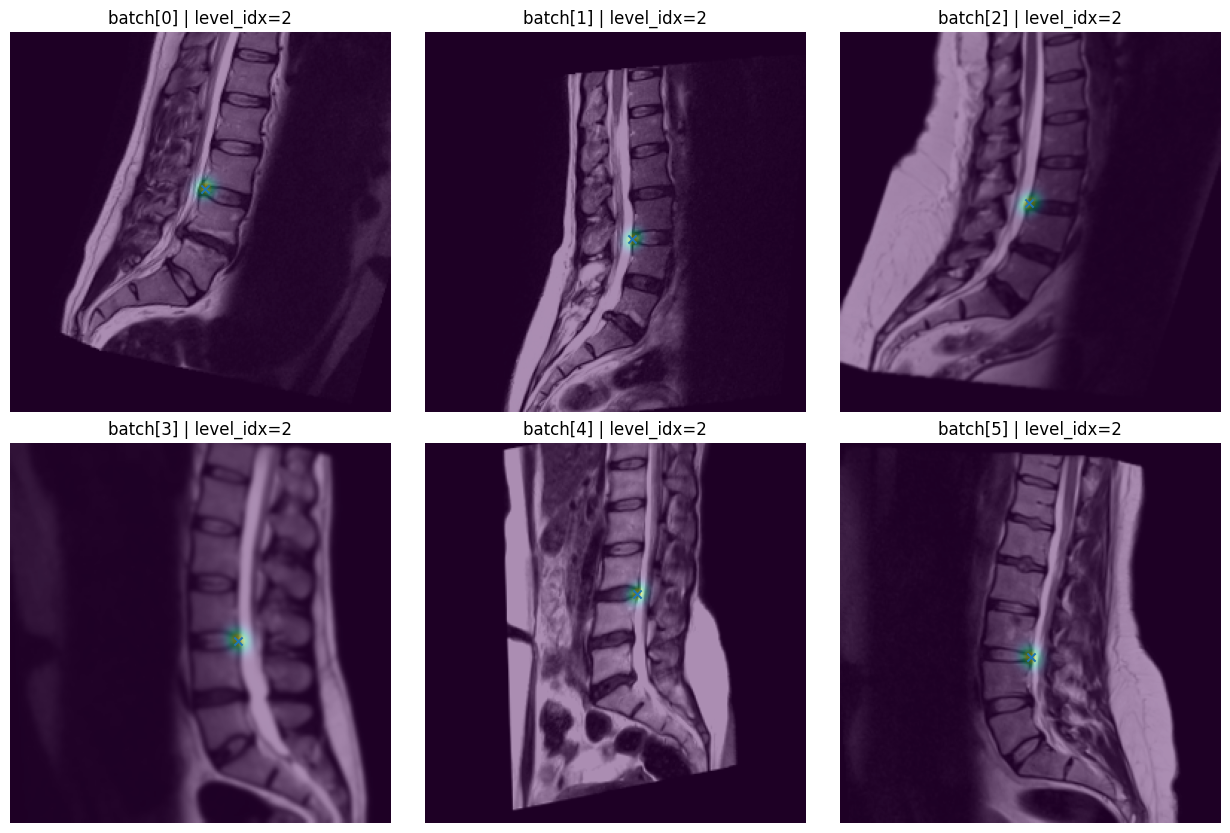

In [13]:
visualize_training_batch(train_loader, mean=mean, std=std, level_idx=2)

## Models training

In [14]:
# CONFIG: 

class WeightedMSELoss(nn.Module):
    def __init__(self, alpha=10.0):
        super().__init__()
        self.alpha = float(alpha)

    def forward(self, pred, target):
        w = 1.0 + self.alpha * target
        return (w * (pred - target) ** 2).mean()

num_epochs = 30
patience   = 10
criterion = WeightedMSELoss(alpha=10.0)

# --- optional schedules ---
dynamic_sigma_reduction = True
resolution_increasing   = False

# sigma schedule (only used if dynamic_sigma_reduction=True)
sigma_start = 10.0
sigma_end   = 3.0

# resolution schedule (only used if resolution_increasing=True) -> NOT APPLIED 
res_start = 128
res_end   = 256

# AMP
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

best_val_loss = math.inf
best_state = None
epochs_without_improve = 0

# convenience: dataset refs (must have set_sigma/set_img_size)
train_ds_ref = train_loader.dataset
val_ds_ref   = val_loader.dataset


/tmp/ipykernel_2684662/2719208181.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


### U-Net

In [46]:
model1 = UNet(
    in_channels=1,   # grayscale
    n_classes=5,
).to(device)

optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-4)

print("Model ready on", device)

total_params = sum(p.numel() for p in model1.parameters())
print(f"Total parameters: {total_params:,}")

Model ready on cuda
Total parameters: 31,036,741



Epoch 1/30
  schedule -> sigma=5.000 | res=256


/tmp/ipykernel_2684662/3113231369.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2684662/355154181.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Train loss: 0.013850
  Val   loss: 0.008702
  -> New best model (kept in memory).

Epoch 2/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.008335
  Val   loss: 0.008647
  -> No improvement (1/10)

Epoch 3/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.007296
  Val   loss: 0.007106
  -> New best model (kept in memory).

Epoch 4/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006735
  Val   loss: 0.006881
  -> New best model (kept in memory).

Epoch 5/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006638
  Val   loss: 0.006813
  -> No improvement (1/10)

Epoch 6/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006643
  Val   loss: 0.007005
  -> No improvement (2/10)

Epoch 7/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006155
  Val   loss: 0.006337
  -> New best model (kept in memory).

Epoch 8/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006110
  Val   loss: 0.006121
  -> New best model (kept in memory).

Epoch 9/30
  schedule ->

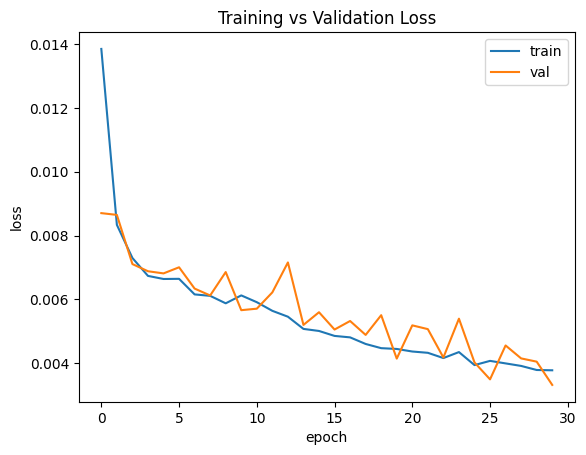

In [47]:
model1, history1 = training_static_aug(
    model=model1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer1,
    device=device,
    criterion=criterion,
    num_epochs=30,
    patience=10,
    dynamic_sigma_reduction=False,
    resolution_increasing=False,
)

### Res-U-Net

In [17]:
model2 = ResUNet(
    in_channels=1,   # grayscale
    n_classes=5,
    base_c=64        # matches the diagram; you can use 32 if you want smaller model
).to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)

print("Model ready on", device)

total_params = sum(p.numel() for p in model2.parameters())
print(f"Total parameters: {total_params:,}")

Model ready on cuda
Total parameters: 32,435,333



Epoch 1/30
  schedule -> sigma=5.000 | res=256


/tmp/ipykernel_2684662/3113231369.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2684662/355154181.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Train loss: 0.023266
  Val   loss: 0.009996
  -> New best model (kept in memory).

Epoch 2/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.007855
  Val   loss: 0.008588
  -> New best model (kept in memory).

Epoch 3/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006912
  Val   loss: 0.007471
  -> New best model (kept in memory).

Epoch 4/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006626
  Val   loss: 0.008559
  -> No improvement (1/10)

Epoch 5/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006394
  Val   loss: 0.006955
  -> New best model (kept in memory).

Epoch 6/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006223
  Val   loss: 0.007600
  -> No improvement (1/10)

Epoch 7/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.005856
  Val   loss: 0.006501
  -> New best model (kept in memory).

Epoch 8/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.005713
  Val   loss: 0.008844
  -> No improvement (1/10)

Epoch 9/30
  schedule ->

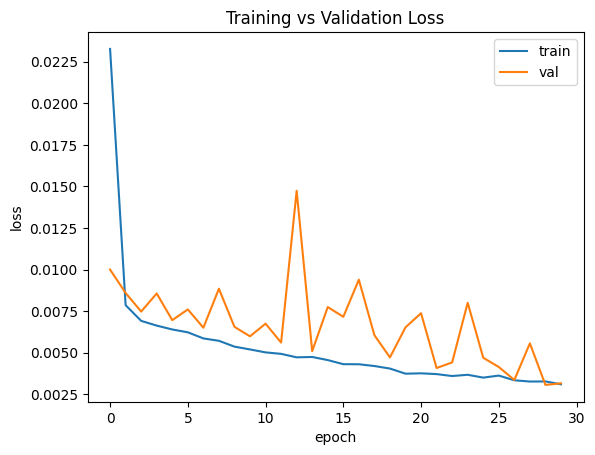

In [19]:
model2, history2 = training_static_aug(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer2,
    device=device,
    criterion=criterion,
    num_epochs=30,
    patience=10,
    dynamic_sigma_reduction=False,
    resolution_increasing=False,
)


### Attention Res U-Net

In [53]:
model3 = AttentionResUNet(
    in_channels=1,   # grayscale
    n_classes=5,
    base_c=64  
).to(device)

optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3, weight_decay=1e-4)

print("Model ready on", device)

total_params = sum(p.numel() for p in model3.parameters())
print(f"Total parameters: {total_params:,}")

Model ready on cuda
Total parameters: 32,785,905



Epoch 1/30
  schedule -> sigma=5.000 | res=256


/tmp/ipykernel_2684662/3113231369.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_2684662/355154181.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Train loss: 0.020148
  Val   loss: 0.008992
  -> New best model (kept in memory).

Epoch 2/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.008550
  Val   loss: 0.008973
  -> No improvement (1/10)

Epoch 3/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.007682
  Val   loss: 0.012514
  -> No improvement (2/10)

Epoch 4/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006800
  Val   loss: 0.007495
  -> New best model (kept in memory).

Epoch 5/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006430
  Val   loss: 0.007335
  -> New best model (kept in memory).

Epoch 6/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.006293
  Val   loss: 0.007076
  -> New best model (kept in memory).

Epoch 7/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.005887
  Val   loss: 0.008299
  -> No improvement (1/10)

Epoch 8/30
  schedule -> sigma=5.000 | res=256
  Train loss: 0.005747
  Val   loss: 0.005398
  -> New best model (kept in memory).

Epoch 9/30
  schedule ->

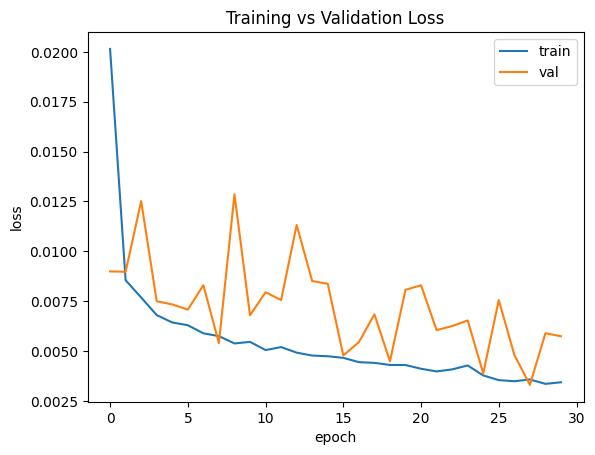

In [54]:
model3, history3 = training_static_aug(
    model=model3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer3,
    device=device,
    criterion=criterion,
    num_epochs=30,
    patience=10,
    dynamic_sigma_reduction=False,
    resolution_increasing=False,
)

## Models Evaluation
The primary evaluation metric is **pixel localization error**:

- Euclidean distance (in pixels) between:
  - Ground truth heatmap argmax
  - Predicted heatmap argmax

Reported metrics include:
- Per-level mean pixel error
- Overall mean pixel error
- Overall 90th percentile (p90) pixel error

“Among the evaluated architectures, Res-UNet achieves the best trade-off between accuracy and robustness, reducing both mean and extreme pixel localization errors across all vertebral levels.”

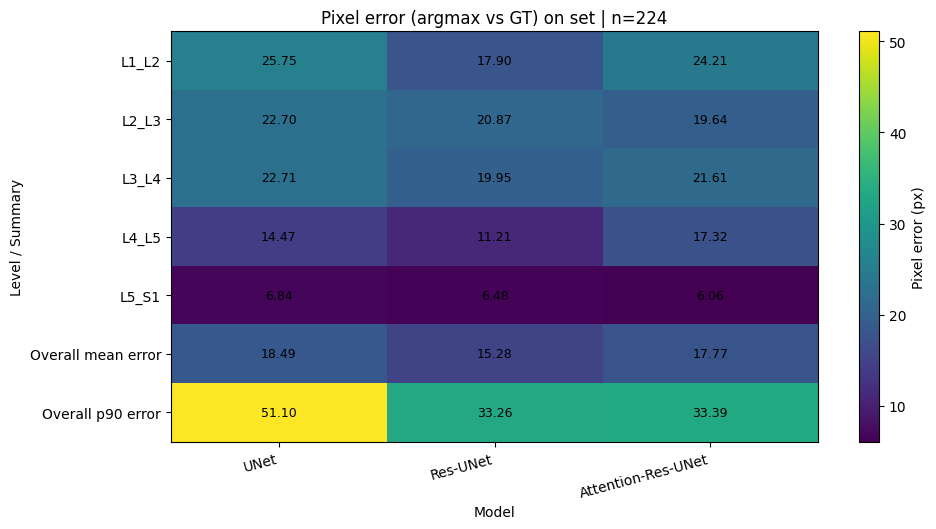

In [66]:
# Validation
table_val, rows_val = compare_models_pixel_error_heatmap(
    models=[model1, model2, model3],
    model_names=["UNet", "Res-UNet", "Attention-Res-UNet"],
    loader=val_loader,
    device=device,
    use_amp=True,
)

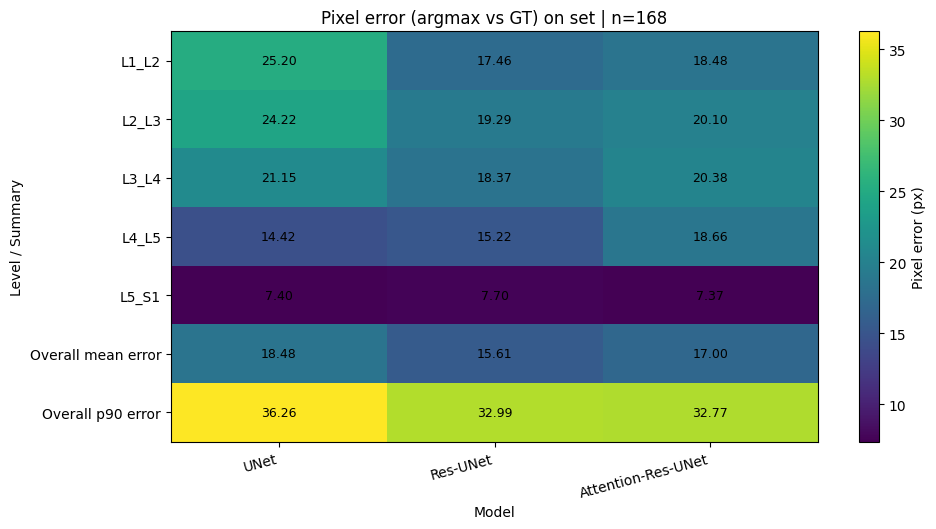

In [68]:
# Test
table_test, rows_test = compare_models_pixel_error_heatmap(
    models=[model1, model2, model3],
    model_names=["UNet", "Res-UNet", "Attention-Res-UNet"],
    loader=test_loader,
    device=device,
    use_amp=True,
)

### Best models performance visualization


Visualizing val sample 0/223


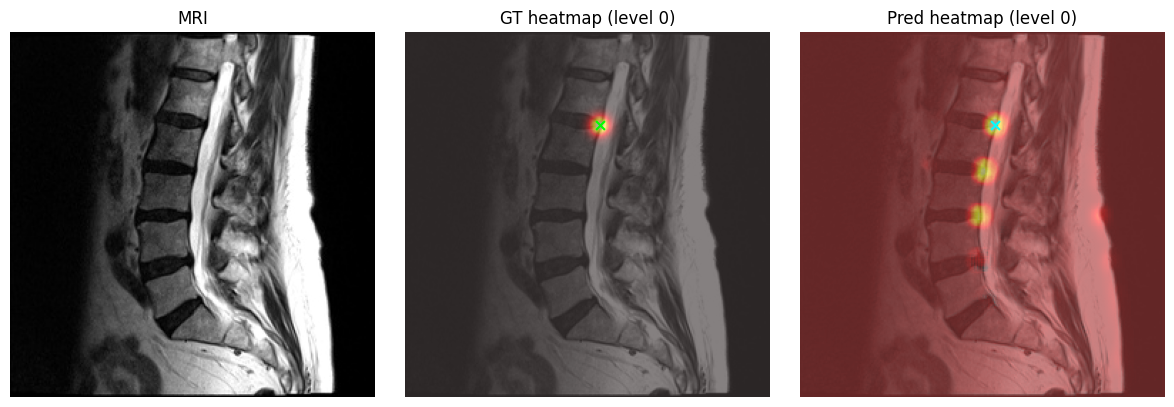


Visualizing val sample 1/223


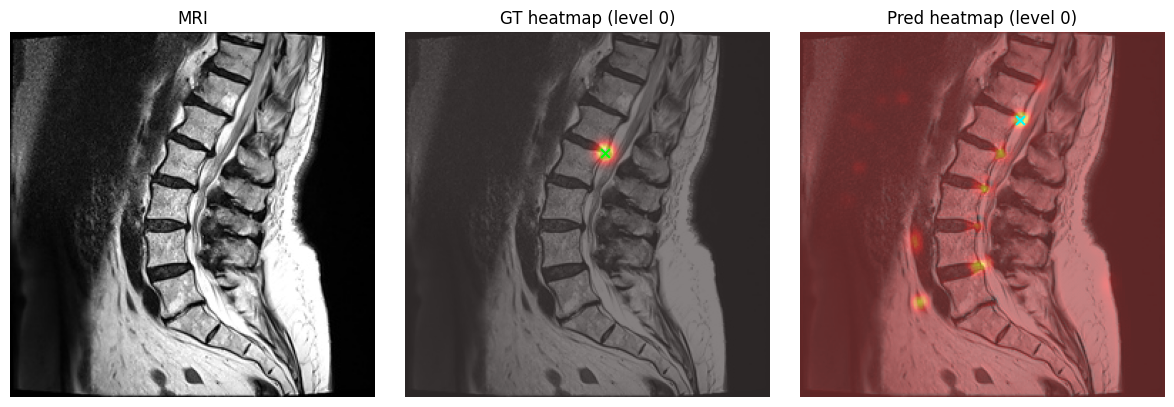


Visualizing val sample 2/223


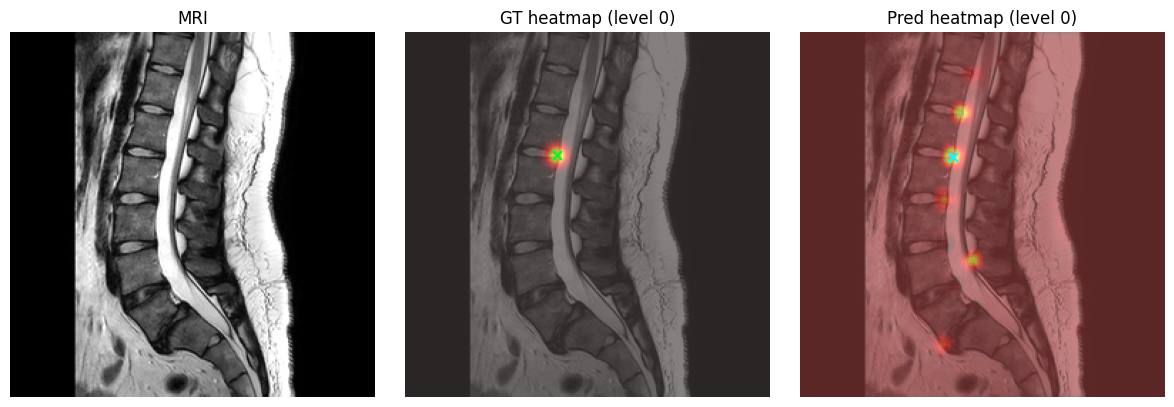


Visualizing val sample 3/223


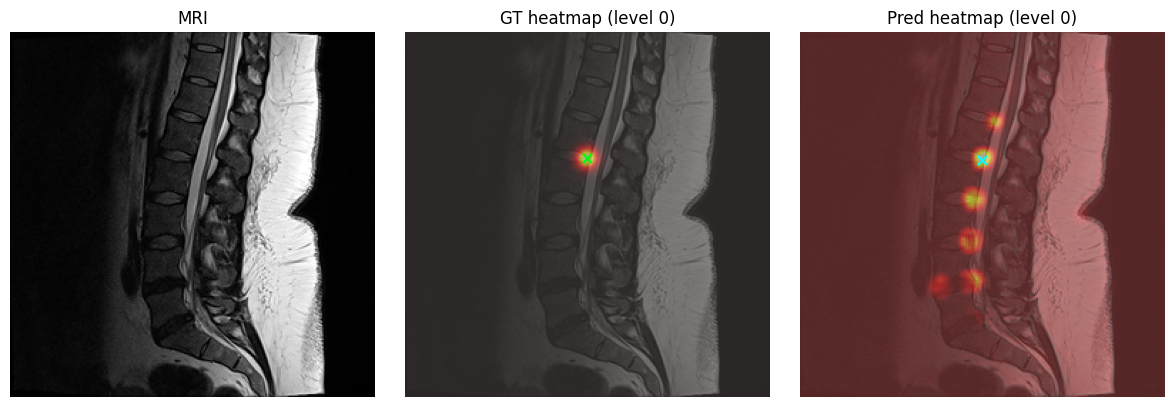


Visualizing val sample 4/223


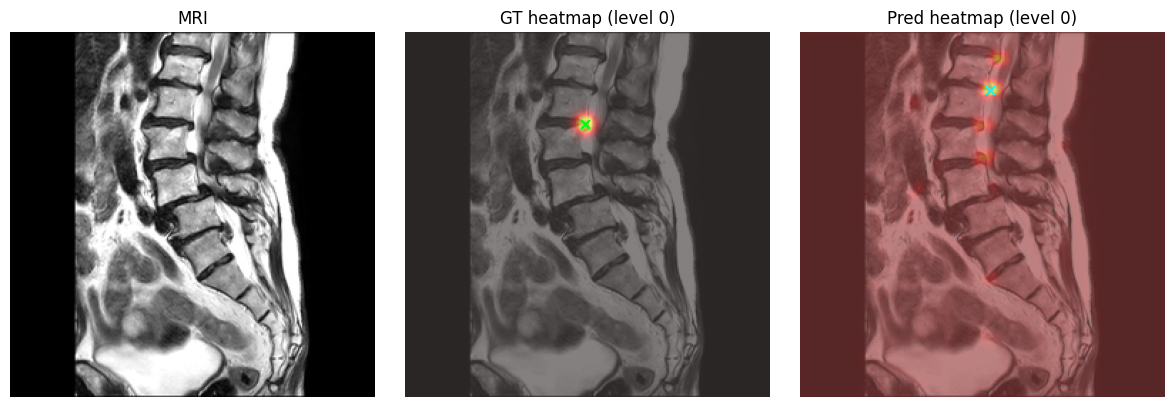

In [72]:
mean_t = torch.tensor(mean, dtype=torch.float32)
std_t  = torch.tensor(std,  dtype=torch.float32)

for idx in range(15):
    print(f"\nVisualizing val sample {idx}/{len(val_ds)-1}")

    visualize_sample(
        model=model2,
        dataset= test_ds,
        idx=idx,
        device=device,
        mean=mean_t,
        std=std_t,
    )